# Customer Segmentation Analysis

## Objective
The objective of this project is to segment customers based on their purchasing behavior using KMeans clustering.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv(r"D:\internship\retail_sales_dataset.csv")

In [3]:
df[['Customer ID', 'Age', 'Quantity', 'Total Amount']].head()

,Customer ID,Age,Quantity,Total Amount
0,CUST001,34,3,150
1,CUST002,26,2,1000
2,CUST003,50,1,30
3,CUST004,37,1,500
4,CUST005,30,2,100


In [4]:
customer_data = df.groupby('Customer ID').agg({
    'Total Amount': 'sum',
    'Quantity': 'sum'
}).reset_index()

customer_data.head()

,Customer ID,Total Amount,Quantity
0,CUST001,150,3
1,CUST002,1000,2
2,CUST003,30,1
3,CUST004,500,1
4,CUST005,100,2


In [5]:
X = customer_data[['Total Amount', 'Quantity']]

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)

customer_data['Cluster'] = kmeans.fit_predict(X)

customer_data.head()

,Customer ID,Total Amount,Quantity,Cluster
0,CUST001,150,3,0
1,CUST002,1000,2,1
2,CUST003,30,1,0
3,CUST004,500,1,0
4,CUST005,100,2,0


In [7]:
customer_data.groupby('Cluster')[['Total Amount', 'Quantity']].mean()

,Total Amount,Quantity
Cluster,,
0,154.076087,2.266304
1,1137.674419,3.023256
2,2000.000000,4.000000


In [8]:
cluster_names = {
    0: 'Low Value',
    1: 'Medium Value',
    2: 'High Value'
}

customer_data['Customer Segment'] = customer_data['Cluster'].map(cluster_names)

customer_data.head()

,Customer ID,Total Amount,Quantity,Cluster,Customer Segment
0,CUST001,150,3,0,Low Value
1,CUST002,1000,2,1,Medium Value
2,CUST003,30,1,0,Low Value
3,CUST004,500,1,0,Low Value
4,CUST005,100,2,0,Low Value


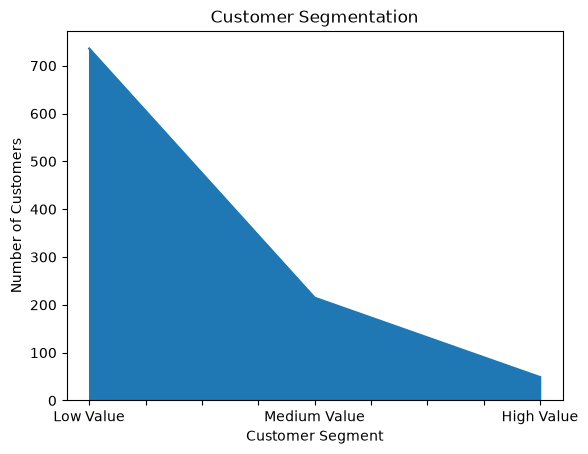

In [17]:
customer_data['Customer Segment'].value_counts().plot(
    kind='area'
)

plt.title('Customer Segmentation')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.show()

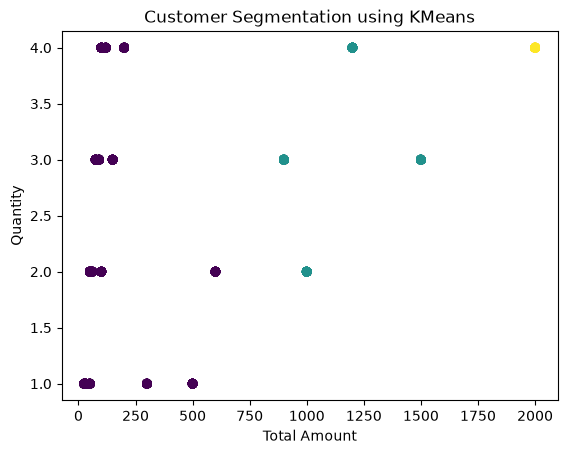

In [10]:
plt.scatter(
    customer_data['Total Amount'],
    customer_data['Quantity'],
    c=customer_data['Cluster']
)

plt.title('Customer Segmentation using KMeans')
plt.xlabel('Total Amount')
plt.ylabel('Quantity')

plt.show()

In [11]:
print("""
BUSINESS INSIGHTS:

1. Customers were successfully segmented into three groups using KMeans clustering.
2. Low Value customers have lower spending and purchase quantity.
3. Medium Value customers have moderate spending behavior.
4. High Value customers generate the highest revenue and purchase more products.
5. Customer segmentation can help businesses create targeted marketing strategies.
6. High Value customers can be given special offers and loyalty rewards.
""")


BUSINESS INSIGHTS:

1. Customers were successfully segmented into three groups using KMeans clustering.
2. Low Value customers have lower spending and purchase quantity.
3. Medium Value customers have moderate spending behavior.
4. High Value customers generate the highest revenue and purchase more products.
5. Customer segmentation can help businesses create targeted marketing strategies.
6. High Value customers can be given special offers and loyalty rewards.



## Conclusion

Customers were successfully divided into three segments: Low Value, Medium Value, and High Value customers. KMeans clustering helped identify different customer purchasing behaviors based on Total Amount and Quantity. This analysis can help businesses create targeted marketing strategies and improve customer engagement.